In [46]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [47]:
image_path = '/Users/arhaan/Documents/Codes/Image processing/Screenshot 2025-12-31 at 12.53.46 AM.png'

In [48]:
def load_and_prep(image_path):
    raw_image = Image.open(image_path).convert("RGB")

    prep_image = transforms.ToTensor()(raw_image)

    batched_tensor = prep_image.unsqueeze(0)

    return batched_tensor,raw_image

In [49]:
import torch.nn.functional as F

def padding(batched_tensor):

    pad_config = (1,1,1,1)

    pad_tensor = F.pad(batched_tensor,pad_config,mode='replicate')

    return pad_tensor

In [ ]:
input_tensor , old_PIL = load_and_prep(image_path)

padded_tensor = padding(input_tensor)

print(f"Original tensor is : {input_tensor.shape}")
print(f"Padded tensor is : {padded_tensor.shape}")
print(f"Size of image is(W,H) : {old_PIL.size}")



Original tensor is : torch.Size([1, 3, 210, 130])
Padded tensor is : torch.Size([1, 3, 212, 132])
Size of image is : (130, 210)


In [51]:
#not taking the dimesion of padding...
old_h = input_tensor.shape[2]
old_w = input_tensor.shape[3]

new_h = 4000
new_w = 4000

ratio_h = old_h/new_h
ratio_w = old_w/new_w

In [52]:
new_image = torch.zeros((1,3,new_h,new_w))

In [53]:
def bilinear_interpolation(padded_tensor):
    for x_out in range(new_w):
        for y_out in range(new_h):
            
            src_add_x = x_out*ratio_w
            src_add_y = y_out*ratio_h

            left_x = int(src_add_x)
            top_y = int(src_add_y)

            right_x = left_x + 1
            bot_y = top_y + 1

            dx = src_add_x - left_x
            dy = src_add_y - top_y

            Rtop =  padded_tensor[:,:,top_y,left_x]*(1-dx) + padded_tensor[:,:,top_y,right_x]*dx
            Rbot =  padded_tensor[:,:,bot_y,left_x]*(1-dx) + padded_tensor[:,:,bot_y,right_x]*dx

            final_pixel = Rtop*(1-dy) + Rbot*(dy)


            new_image[:,:,y_out,x_out] = final_pixel

    return new_image            

In [ ]:
def visualize_result(tensor_image):
    # 1. Clean up the data
    # Clone it so we don't mess up the original calculation
    #image_to_show = tensor_image.clone().detach().cpu()
    
    # 2. Remove the batch dimension (The '1')
    # Shape: [1, 3, H, W] -> [3, H, W]
    image_to_show = tensor_image.squeeze(0)
    
    # 3. Swap dimensions for Matplotlib
    # Shape: [3, H, W] -> [H, W, 3] (Channels Last)
    image_to_show = image_to_show.permute(1, 2, 0)
    
    # 4. Render
    plt.figure(figsize=(10, 10))
    plt.imshow(image_to_show)
    plt.axis('off') # Hide the ugly axis numbers
    plt.title("Bilinear")
    plt.show()

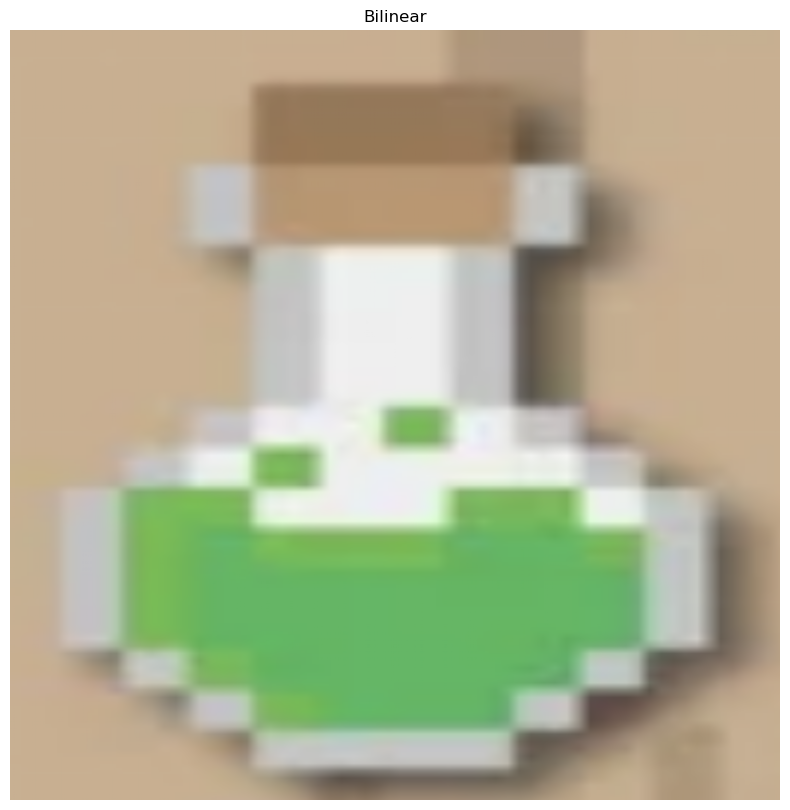

FInal shape : torch.Size([1, 3, 4000, 4000])


In [55]:
final_output = bilinear_interpolation(padded_tensor)

visualize_result(final_output)

print(f"FInal shape : {final_output.shape}")